# CS802 Section 1 - Perceptron Baseline

This notebook implements perceptron baselines for Sign Language MNIST from scratch in NumPy. The analysis focuses on how far a linear model can go on flattened image pixels before moving to non-linear neural networks.

1. step activation with online learning,
2. full-batch perceptron learning,
3. sigmoid activation,
4. one-vs-rest multi-class classification,
5. weight printing and visual analysis of Sign Language MNIST samples.

## Methodological scope

The perceptron experiments are designed to make the learning rule, activation choice and interpretability checks explicit:

- use explicit vector/matrix multiplication with the `@` operator;
- explain sigmoid clipping as a numerical-stability safeguard;
- report bias, weight statistics and influential positive/negative pixels;
- visualise representative training examples and learned weight maps;
- compare learning-rate and iteration choices for binary and one-vs-rest settings.


## Setup: imports, constants, and helper functions

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# The notebooks can be run either from the repository root or from the notebooks/ folder.
# The first existing directory containing the CSV files is used.
CANDIDATE_DATA_DIRS = [Path("../data/raw"), Path("data/raw"), Path(".")]
DATA_DIR = next(
    (path for path in CANDIDATE_DATA_DIRS if (path / "sign_mnist_train.csv").exists()),
    CANDIDATE_DATA_DIRS[0],
)

LETTERS = list("ABCDEFGHIKLMNOPQRSTUVWXY")  # J and Z are excluded in Sign Language MNIST.
LABEL_TO_LETTER = {i: letter for i, letter in enumerate(LETTERS)}
NUM_CLASSES = 24
TARGET_CLASS = 2  # Class C is used for the binary one-vs-rest experiments.


In [2]:
# Quick helper function to handle the CSV loading
def _read_sign_csv(csv_path):
    """Read either a headerless local CSV or the Kaggle CSV format with a header."""
    preview = pd.read_csv(csv_path, header=None, nrows=3)
    first_value = str(preview.iloc[0, 0]).strip().lower()
    if first_value == "label":
        return pd.read_csv(csv_path)
    return pd.read_csv(csv_path, header=None)

def load_sign_mnist(csv_path, normalize=True, add_bias=False):
    """Load Sign Language MNIST and optionally prepend a bias column of ones."""
    df = _read_sign_csv(csv_path)
    y = pd.to_numeric(df.iloc[:, 0], errors="raise").to_numpy(dtype=np.int64)
    X = df.iloc[:, 1:].to_numpy(dtype=np.float32)
    if normalize:
        X = X / 255.0
    if add_bias:
        bias = np.ones((X.shape[0], 1), dtype=np.float32)
        X = np.hstack([bias, X]).astype(np.float32)
    return X, y

def make_binary_labels(y, positive_label):
    return (np.asarray(y) == positive_label).astype(np.int64)

def one_hot_encode(y, num_classes=NUM_CLASSES):
    y = np.asarray(y).astype(np.int64)
    out = np.zeros((len(y), num_classes), dtype=np.float32)
    out[np.arange(len(y)), y] = 1.0
    return out

In [3]:
# Metrics and visualisation utilities
def binary_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(np.int64).ravel()
    y_pred = np.asarray(y_pred).astype(np.int64).ravel()

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    return {
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "accuracy": float((tp + tn) / len(y_true)),
        "precision": float(tp / (tp + fp)) if (tp + fp) else 0.0,
        "recall": float(tp / (tp + fn)) if (tp + fn) else 0.0,
    }

def confusion_matrix_manual(y_true, y_pred, num_classes=NUM_CLASSES):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for true_label, pred_label in zip(np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()):
        if 0 <= true_label < num_classes and 0 <= pred_label < num_classes:
            cm[int(true_label), int(pred_label)] += 1
    return cm

def macro_precision_recall(cm):
    # The provided test split is missing class 23, so the macro average
    # should only use classes that are present in the test set or predicted.
    active_classes = [k for k in range(cm.shape[0]) if (cm[k, :].sum() + cm[:, k].sum()) > 0]
    precisions, recalls = [], []
    for k in active_classes:
        tp = cm[k, k]
        fp = cm[:, k].sum() - tp
        fn = cm[k, :].sum() - tp
        precisions.append(tp / (tp + fp) if (tp + fp) else 0.0)
        recalls.append(tp / (tp + fn) if (tp + fn) else 0.0)
    return float(np.mean(precisions)), float(np.mean(recalls))

def class_distribution(y):
    counts = pd.Series(np.asarray(y)).value_counts().sort_index()
    return pd.DataFrame({
        "label": counts.index,
        "letter": [LABEL_TO_LETTER[i] for i in counts.index],
        "count": counts.values,
    })

def show_example(X, y, label_id, title_prefix="Example"):
    idx = np.where(np.asarray(y) == label_id)[0][0]
    image = X[idx]
    if image.shape[0] == 785:
        image = image[1:]  # remove bias for visualisation
    plt.figure(figsize=(3, 3))
    plt.imshow(image.reshape(28, 28), cmap="gray")
    plt.title(f"{title_prefix}: class {label_id} = {LABEL_TO_LETTER[label_id]}")
    plt.axis("off")
    plt.show()

def plot_weight_image(weights, title="Learned weights"):
    weight_vector = np.asarray(weights)
    if weight_vector.shape[0] == 785:
        weight_vector = weight_vector[1:]  # remove bias before reshaping
    plt.figure(figsize=(4, 4))
    plt.imshow(weight_vector.reshape(28, 28), cmap="coolwarm")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(title)
    plt.axis("off")
    plt.show()

def plot_history(history, title="Training history"):
    hist = pd.DataFrame(history)
    if hist.empty:
        return
    plt.figure(figsize=(6, 4))
    if "mse" in hist.columns:
        plt.plot(hist["epoch"], hist["mse"], marker="o")
        plt.ylabel("MSE")
    elif "updates" in hist.columns:
        plt.plot(hist["epoch"], hist["updates"], marker="o")
        plt.ylabel("Updates")
    plt.xlabel("Epoch")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

def plot_confusion_matrix(cm, labels=None, title="Confusion matrix", figsize=(8, 8)):
    if labels is None:
        labels = [LABEL_TO_LETTER[i] for i in range(cm.shape[0])]
    plt.figure(figsize=figsize)
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def plot_class_examples(X, y, title="One example from each class", cols=6):
    """Display one 28x28 Sign Language MNIST image for every available class."""
    y_array = np.asarray(y).astype(np.int64)
    available_labels = [label for label in range(NUM_CLASSES) if np.any(y_array == label)]
    rows = int(np.ceil(len(available_labels) / cols))

    plt.figure(figsize=(cols * 2.0, rows * 2.0))
    for plot_idx, label_id in enumerate(available_labels, start=1):
        sample_idx = np.where(y_array == label_id)[0][0]
        image = np.asarray(X[sample_idx])
        if image.shape[0] == 785:
            image = image[1:]  # Drop the bias column before reshaping to 28x28.

        plt.subplot(rows, cols, plot_idx)
        plt.imshow(image.reshape(28, 28), cmap="gray")
        plt.title(f"{LABEL_TO_LETTER[label_id]} ({label_id})")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def _weights_without_bias(weights):
    """Return a 784-pixel weight vector, removing the bias term if present."""
    weight_vector = np.asarray(weights, dtype=np.float32).ravel()
    return weight_vector[1:] if weight_vector.shape[0] == 785 else weight_vector


def plot_weight_grid(weights_by_name, title="Learned weights", cols=4):
    """Visualise learned 28x28 weight maps for several perceptron models."""
    if not weights_by_name:
        return

    names = list(weights_by_name.keys())
    rows = int(np.ceil(len(names) / cols))
    processed = [_weights_without_bias(weights_by_name[name]) for name in names]
    max_abs_weight = max(float(np.max(np.abs(vec))) for vec in processed)
    max_abs_weight = max(max_abs_weight, 1e-8)

    plt.figure(figsize=(cols * 3.0, rows * 3.0))
    for plot_idx, (name, weight_vector) in enumerate(zip(names, processed), start=1):
        plt.subplot(rows, cols, plot_idx)
        plt.imshow(
            weight_vector.reshape(28, 28),
            cmap="coolwarm",
            vmin=-max_abs_weight,
            vmax=max_abs_weight,
        )
        plt.title(name)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


## 1.1-1.3 Perceptron class

The class below implements the perceptron functionality used in the experiments:

- `predict()` with step or sigmoid activation,
- `train()` for online learning,
- `train_batch()` for full-batch learning,
- `test()` for accuracy, precision, and recall,
- `print_weights()` for an interpretable summary of learned parameters.

Two implementation details are important for numerical clarity:

1. The core score is computed with `x @ weights` rather than `np.dot`. For a single flattened image this gives the same scalar result, but the `@` operator is clearer and consistent with vectorised matrix multiplication used in batch learning.
2. Sigmoid inputs are clipped to `[-40, 40]`. This prevents overflow in `np.exp(-a)` for very large positive or negative scores. It does not materially change the binary decision because sigmoid is already saturated very close to 0 or 1 outside this range.


In [4]:
class Perceptron:
    """A from-scratch perceptron for binary classification.

    The model supports two activation functions and two training styles:
    online learning updates after each sample, while full-batch learning
    accumulates the average update over the entire training set once per epoch.
    """

    def __init__(self, no_inputs, max_iterations=20, learning_rate=0.1, random_state=42):
        self.no_inputs = int(no_inputs)
        self.max_iterations = int(max_iterations)
        self.learning_rate = float(learning_rate)
        self.random_state = int(random_state)

        # Small random values break symmetry and avoid the unstable behaviour that
        # can occur when all weights start with the same value.
        rng = np.random.default_rng(self.random_state)
        self.weights = rng.normal(0.0, 0.01, size=self.no_inputs).astype(np.float32)
        self.history = []

    def print_details(self):
        """Print the main training settings for quick inspection."""
        print("No. inputs:\t", self.no_inputs)
        print("Max iterations:\t", self.max_iterations)
        print("Learning rate:\t", self.learning_rate)

    def print_weights(self, top_n=10):
        """Print and return a compact summary of the learned weights.

        The table highlights the pixels with the strongest positive and negative
        influence on the classifier. This is useful for comparing different
        activation/training configurations.
        """
        weight_vector = np.asarray(self.weights, dtype=np.float32).ravel()
        has_bias = weight_vector.shape[0] == 785
        pixel_weights = weight_vector[1:] if has_bias else weight_vector

        print("Bias weight:", float(weight_vector[0]) if has_bias else "not used")
        print("Weight mean:", float(pixel_weights.mean()))
        print("Weight std :", float(pixel_weights.std()))
        print("Min / max  :", float(pixel_weights.min()), "/", float(pixel_weights.max()))

        top_positive = np.argsort(pixel_weights)[-top_n:][::-1]
        top_negative = np.argsort(pixel_weights)[:top_n]

        summary = pd.DataFrame({
            "rank": np.arange(1, top_n + 1),
            "positive_pixel": top_positive,
            "positive_weight": pixel_weights[top_positive],
            "negative_pixel": top_negative,
            "negative_weight": pixel_weights[top_negative],
        })
        return summary

    # Activation functions
    def sigmoid(self, a):
        # Clipping prevents overflow in exp for large-magnitude scores. Values
        # outside [-40, 40] already map to probabilities extremely close to 0/1.
        clipped = np.clip(a, -40, 40)
        return 1.0 / (1.0 + np.exp(-clipped))

    def step(self, a):
        return np.where(np.asarray(a) > 0, 1.0, 0.0)

    def decision_function(self, x):
        """Return the linear score before activation.

        The `@` operator is used intentionally here. It is the clearest notation
        for matrix/vector multiplication and is consistent with the batch code.
        """
        x = np.asarray(x, dtype=np.float32)
        score = x @ self.weights
        return float(score) if np.ndim(score) == 0 else score

    def predict_score(self, x, activation="step"):
        """Return a confidence-like score used by one-vs-rest classification."""
        activation = activation.lower()
        activation_value = self.decision_function(x)

        if activation == "step":
            return activation_value
        if activation == "sigmoid":
            return float(self.sigmoid(activation_value))
        raise ValueError("activation must be 'step' or 'sigmoid'")

    def predict(self, x, activation="step"):
        """Predict a binary class label for one sample."""
        activation = activation.lower()
        activation_value = self.decision_function(x)

        if activation == "step":
            return int(self.step(activation_value))
        if activation == "sigmoid":
            return int(self.sigmoid(activation_value) >= 0.5)
        raise ValueError("activation must be 'step' or 'sigmoid'")

    def train(self, training_data, labels, activation="step", shuffle=True):
        """Online learning: update weights after every training sample."""
        activation = activation.lower()
        X = np.asarray(training_data, dtype=np.float32)
        y = np.asarray(labels, dtype=np.float32).ravel()

        if len(X) != len(y):
            raise ValueError("training_data and labels must contain the same number of rows")

        rng = np.random.default_rng(self.random_state)
        self.history = []

        for epoch in range(self.max_iterations):
            indices = np.arange(len(X))
            if shuffle:
                rng.shuffle(indices)

            squared_error = 0.0
            updates = 0

            for idx in indices:
                x = X[idx]
                target = y[idx]
                activation_value = self.decision_function(x)

                if activation == "step":
                    output = float(self.step(activation_value))
                    delta = target - output
                elif activation == "sigmoid":
                    output = float(self.sigmoid(activation_value))
                    # Gradient for sigmoid output: error multiplied by sigmoid derivative.
                    delta = (target - output) * output * (1.0 - output)
                else:
                    raise ValueError("activation must be 'step' or 'sigmoid'")

                self.weights += self.learning_rate * delta * x
                squared_error += float((target - output) ** 2)
                updates += int(abs(delta) > 0)

            self.history.append({
                "epoch": epoch + 1,
                "mse": squared_error / len(X),
                "updates": updates,
            })

        return self.history

    def train_batch(self, training_data, labels, activation="step", shuffle=True):
        """Full-batch learning: make one averaged weight update per epoch."""
        activation = activation.lower()
        X = np.asarray(training_data, dtype=np.float32)
        y = np.asarray(labels, dtype=np.float32).ravel()

        if len(X) != len(y):
            raise ValueError("training_data and labels must contain the same number of rows")

        rng = np.random.default_rng(self.random_state)
        self.history = []

        for epoch in range(self.max_iterations):
            indices = np.arange(len(X))
            if shuffle:
                rng.shuffle(indices)

            X_epoch = X[indices]
            y_epoch = y[indices]
            activation_values = X_epoch @ self.weights

            if activation == "step":
                outputs = self.step(activation_values).astype(np.float32)
                errors = y_epoch - outputs
            elif activation == "sigmoid":
                outputs = self.sigmoid(activation_values).astype(np.float32)
                # Full-batch sigmoid gradient averaged across all training examples.
                errors = (y_epoch - outputs) * outputs * (1.0 - outputs)
            else:
                raise ValueError("activation must be 'step' or 'sigmoid'")

            weight_update = self.learning_rate * (errors[:, None] * X_epoch).mean(axis=0)
            self.weights += weight_update.astype(np.float32)

            self.history.append({
                "epoch": epoch + 1,
                "mse": float(np.mean((y_epoch - outputs) ** 2)),
                "update_norm": float(np.linalg.norm(weight_update)),
            })

        return self.history

    def test(self, testing_data, labels, activation="step", verbose=True):
        """Evaluate the model on a labelled binary test set."""
        X = np.asarray(testing_data, dtype=np.float32)
        y_true = np.asarray(labels).astype(np.int64).ravel()
        y_pred = np.array([self.predict(x, activation=activation) for x in X], dtype=np.int64)

        metrics = binary_metrics(y_true, y_pred)

        if verbose:
            print("Accuracy:\t", metrics["accuracy"])
            print("Precision:\t", metrics["precision"])
            print("Recall:\t", metrics["recall"])

        return metrics, y_pred


## 1.5 Load the data and inspect examples

This section loads `sign_mnist_train.csv` and `sign_mnist_test.csv`, prepares the binary labels for class C, prints the class distribution, and visualises both a target-class example and one representative image from every available class.


Train X: (27455, 785) Train y: (27455,)
Test X : (7172, 785) Test y : (7172,)
Binary target: 2 C
Positive train samples: 1144
Positive test samples : 310


,label,letter,count
0,0,A,1126
1,1,B,1010
2,2,C,1144
3,3,D,1196
4,4,E,957
5,5,F,1204
6,6,G,1090
7,7,H,1013
8,8,I,1162
9,9,K,1114


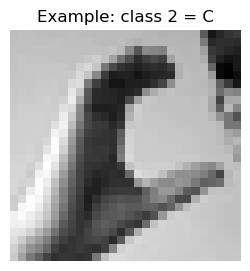

In [5]:
train_path = DATA_DIR / "sign_mnist_train.csv"
test_path = DATA_DIR / "sign_mnist_test.csv"

X_train, y_train = load_sign_mnist(train_path, normalize=True, add_bias=True)
X_test, y_test = load_sign_mnist(test_path, normalize=True, add_bias=True)

y_train_bin = make_binary_labels(y_train, TARGET_CLASS)
y_test_bin = make_binary_labels(y_test, TARGET_CLASS)

print("Train X:", X_train.shape, "Train y:", y_train.shape)
print("Test X :", X_test.shape, "Test y :", y_test.shape)
print("Binary target:", TARGET_CLASS, LABEL_TO_LETTER[TARGET_CLASS])
print("Positive train samples:", int(y_train_bin.sum()))
print("Positive test samples :", int(y_test_bin.sum()))

display(class_distribution(y_train).head(10))
show_example(X_train, y_train, TARGET_CLASS)

plot_class_examples(X_train, y_train, title="Training examples: one image per Sign Language MNIST class")


## 1.1-1.3 Binary experiments: class C vs rest

The four experimental combinations are tested below:

1. step + online,
2. step + full batch,
3. sigmoid + online,
4. sigmoid + full batch.

The positive class is only a small share of the dataset, so I report precision and recall in addition to accuracy. This prevents a majority-class-only classifier from looking better than it really is.

### Hyperparameter rationale

The online models use `learning_rate=0.10` because each update is based on a single example and the model benefits from larger corrective steps. The batch models use a lower rate (`0.01` for the binary task) because the update is averaged over the full training set, making each step smoother but also less noisy. I use 10 iterations for the binary experiments because the training curves flatten quickly and additional epochs add runtime without changing the main comparison. For the multi-class one-vs-rest runs, fewer epochs are used because 24 perceptrons are trained for each configuration.


In [6]:
def run_binary_perceptron_experiment(
    X_train,
    y_train_binary,
    X_test,
    y_test_binary,
    activation="step",
    mode="online",
    max_iterations=10,
    learning_rate=0.1,
    random_state=42,
):
    model = Perceptron(
        no_inputs=X_train.shape[1],
        max_iterations=max_iterations,
        learning_rate=learning_rate,
        random_state=random_state,
    )

    start_time = time.time()

    if mode == "online":
        history = model.train(X_train, y_train_binary, activation=activation)
    elif mode == "batch":
        history = model.train_batch(X_train, y_train_binary, activation=activation)
    else:
        raise ValueError("mode must be 'online' or 'batch'")

    training_time = time.time() - start_time
    metrics, y_pred = model.test(X_test, y_test_binary, activation=activation, verbose=False)

    row = {
        "activation": activation,
        "mode": mode,
        "iterations": max_iterations,
        "learning_rate": learning_rate,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "training_time_sec": training_time,
    }
    return model, history, metrics, y_pred, row

binary_configs = [
    {"activation": "step",    "mode": "online", "max_iterations": 10, "learning_rate": 0.10},
    {"activation": "step",    "mode": "batch",  "max_iterations": 10, "learning_rate": 0.01},
    {"activation": "sigmoid", "mode": "online", "max_iterations": 10, "learning_rate": 0.10},
    {"activation": "sigmoid", "mode": "batch",  "max_iterations": 10, "learning_rate": 0.01},
]

binary_rows = []
binary_runs = {}

for cfg in binary_configs:
    model, history, metrics, y_pred, row = run_binary_perceptron_experiment(
        X_train=X_train,
        y_train_binary=y_train_bin,
        X_test=X_test,
        y_test_binary=y_test_bin,
        **cfg,
    )
    key = f"{cfg['activation']}_{cfg['mode']}"
    binary_runs[key] = {
        "model": model,
        "history": history,
        "metrics": metrics,
        "y_pred": y_pred,
    }
    binary_rows.append(row)

binary_results_df = pd.DataFrame(binary_rows).sort_values(["activation", "mode"]).reset_index(drop=True)
display(binary_results_df)


,activation,mode,iterations,learning_rate,accuracy,precision,recall,training_time_sec
0,sigmoid,batch,10,0.01,0.956776,0.000000,0.000000,1.421201
1,sigmoid,online,10,0.10,0.990658,0.932384,0.845161,4.399552
2,step,batch,10,0.01,0.840491,0.153654,0.596774,1.518458
3,step,online,10,0.10,0.993028,0.967626,0.867742,3.628817


Best binary configuration:


,activation,mode,iterations,learning_rate,accuracy,precision,recall,training_time_sec
3,step,online,10,0.1,0.993028,0.967626,0.867742,3.628817


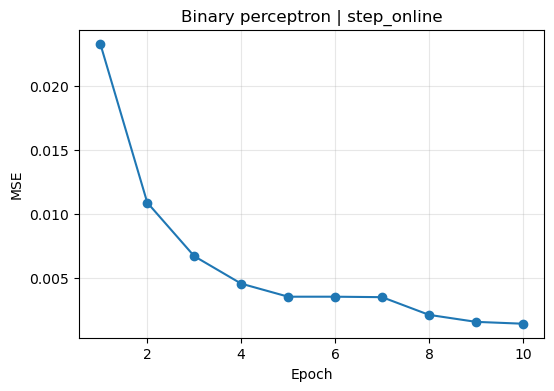

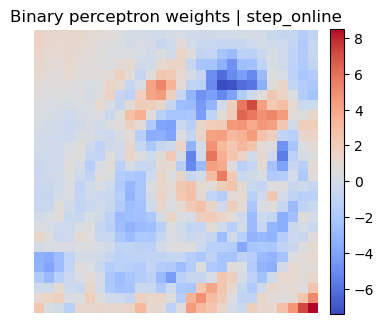

In [7]:
best_binary_row = binary_results_df.sort_values("accuracy", ascending=False).iloc[0]
best_binary_key = f"{best_binary_row['activation']}_{best_binary_row['mode']}"
best_binary_run = binary_runs[best_binary_key]

print("Best binary configuration:")
display(best_binary_row.to_frame().T)

plot_history(best_binary_run["history"], title=f"Binary perceptron | {best_binary_key}")
plot_weight_image(
    best_binary_run["model"].weights,
    title=f"Binary perceptron weights | {best_binary_key}"
)

print("Best binary model weight summary:")
display(best_binary_run["model"].print_weights(top_n=8))

plot_weight_grid(
    {key: run["model"].weights for key, run in binary_runs.items()},
    title="Binary perceptron learned weights across all activation/training configurations",
    cols=4,
)


### Binary interpretation

The strongest binary configuration is **step activation + online learning**. It achieves high accuracy while still maintaining useful precision and recall for the minority target class. This matters because the binary task is imbalanced: predicting only the negative class could produce a deceptively high accuracy but would produce zero recall for class C.

The **sigmoid + batch** configuration is a useful warning example. Its accuracy looks reasonable, but the precision and recall show that it effectively collapses to the majority class. The result supports the decision to report class-sensitive metrics and to compare the learning curves and learned weights rather than relying only on a single accuracy number.

The added weight visualisations make the comparison more interpretable: the best model's weight map shows which image regions support or oppose the class-C decision, and the four-configuration grid shows how the activation/training choice changes the learned linear template.


## 1.4 Multi-class classification (One-vs-Rest)

A single perceptron is a binary classifier, so multi-class prediction is handled with a one-vs-rest strategy. I train 24 separate perceptrons, one for each Sign Language MNIST class. At prediction time, every perceptron produces a score, and the class with the highest score is selected.

This section keeps the same activation/training comparison as the binary task, but it reports macro precision and macro recall because multi-class performance should not be judged only by overall accuracy.


In [8]:
def train_ovr_perceptrons(
    X_train,
    y_train,
    activation="step",
    mode="online",
    max_iterations=5,
    learning_rate=0.1,
    random_state=42,
):
    models = []

    for class_id in range(NUM_CLASSES):
        y_binary = make_binary_labels(y_train, class_id)

        model = Perceptron(
            no_inputs=X_train.shape[1],
            max_iterations=max_iterations,
            learning_rate=learning_rate,
            random_state=random_state + class_id,
        )

        if mode == "online":
            model.train(X_train, y_binary, activation=activation)
        elif mode == "batch":
            model.train_batch(X_train, y_binary, activation=activation)
        else:
            raise ValueError("mode must be 'online' or 'batch'")

        models.append(model)

    return models

def evaluate_multiclass_ovr(models, X_test, y_test, activation="step", print_pairs=False, max_print=20):
    predictions = []

    for i, x in enumerate(X_test):
        
    # Grabbing the prediction from the specific perceptron that is most confident. 
    # np.argmax handles finding the index of the highest score for us.
        scores = np.array([model.predict_score(x, activation=activation) for model in models], dtype=np.float32)
        pred_label = int(np.argmax(scores))
        predictions.append(pred_label)

        if print_pairs:
            if (max_print is None) or (i < max_print):
                print(
                    f"sample {i:04d} | predicted={LABEL_TO_LETTER[pred_label]} ({pred_label}) "
                    f"| true={LABEL_TO_LETTER[int(y_test[i])]} ({int(y_test[i])})"
                )

    y_pred = np.array(predictions, dtype=np.int64)
    cm = confusion_matrix_manual(y_test, y_pred, num_classes=NUM_CLASSES)
    precision_macro, recall_macro = macro_precision_recall(cm)
    accuracy = float(np.mean(y_pred == y_test))

    return {
        "y_pred": y_pred,
        "confusion_matrix": cm,
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
    }

def run_multiclass_perceptron_experiment(
    X_train,
    y_train,
    X_test,
    y_test,
    activation="step",
    mode="online",
    max_iterations=5,
    learning_rate=0.1,
    random_state=42,
):
    start_time = time.time()
    models = train_ovr_perceptrons(
        X_train,
        y_train,
        activation=activation,
        mode=mode,
        max_iterations=max_iterations,
        learning_rate=learning_rate,
        random_state=random_state,
    )
    training_time = time.time() - start_time

    evaluation = evaluate_multiclass_ovr(models, X_test, y_test, activation=activation, print_pairs=False)

    row = {
        "activation": activation,
        "mode": mode,
        "iterations": max_iterations,
        "learning_rate": learning_rate,
        "accuracy": evaluation["accuracy"],
        "precision_macro": evaluation["precision_macro"],
        "recall_macro": evaluation["recall_macro"],
        "training_time_sec": training_time,
    }
    return models, evaluation, row

multiclass_configs = [
    {"activation": "step",    "mode": "online", "max_iterations": 5, "learning_rate": 0.10},
    {"activation": "step",    "mode": "batch",  "max_iterations": 8, "learning_rate": 0.10},
    {"activation": "sigmoid", "mode": "online", "max_iterations": 5, "learning_rate": 0.10},
    {"activation": "sigmoid", "mode": "batch",  "max_iterations": 8, "learning_rate": 0.01},
]

multiclass_rows = []
multiclass_models = {}
multiclass_eval = {}

for cfg in multiclass_configs:
    models, evaluation, row = run_multiclass_perceptron_experiment(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        **cfg,
    )
    key = f"{cfg['activation']}_{cfg['mode']}"
    multiclass_models[key] = models
    multiclass_eval[key] = evaluation
    multiclass_rows.append(row)

multiclass_results_df = pd.DataFrame(multiclass_rows).sort_values(["activation", "mode"]).reset_index(drop=True)
display(multiclass_results_df)


,activation,mode,iterations,learning_rate,accuracy,precision_macro,recall_macro,training_time_sec
0,sigmoid,batch,8,0.01,0.031233,0.022387,0.027541,28.618583
1,sigmoid,online,5,0.10,0.378137,0.318149,0.305569,57.428890
2,step,batch,8,0.10,0.028723,0.001249,0.043478,29.705404
3,step,online,5,0.10,0.334914,0.332352,0.293299,43.417899


Best multi-class configuration:


,activation,mode,iterations,learning_rate,accuracy,precision_macro,recall_macro,training_time_sec
1,sigmoid,online,5,0.1,0.378137,0.318149,0.305569,57.42889


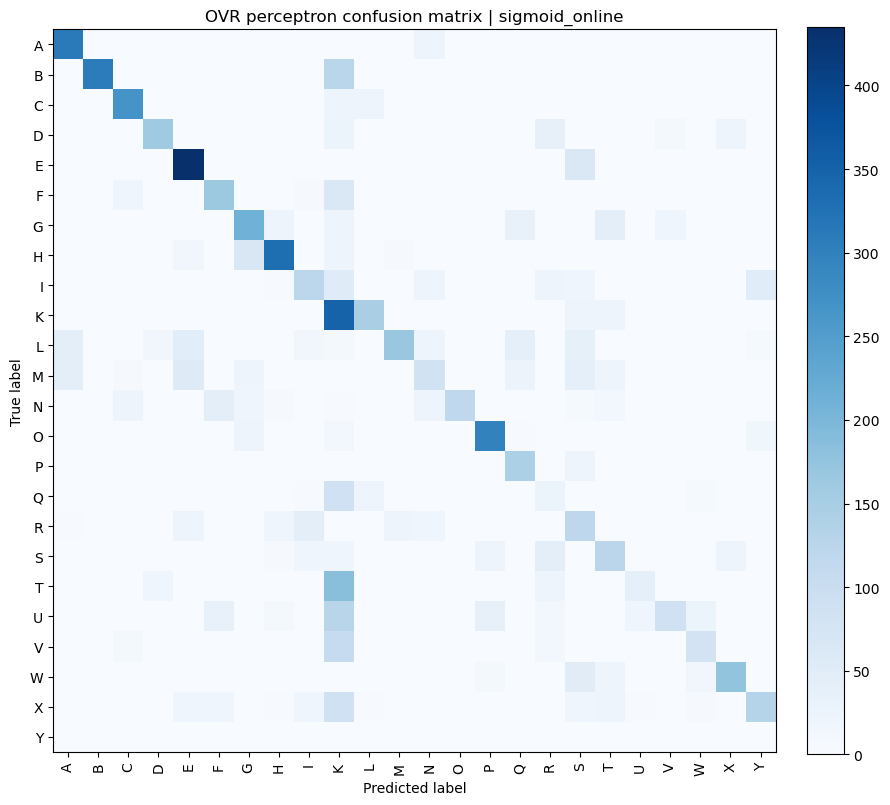

sample 0000 | predicted=G (6) | true=G (6)
sample 0001 | predicted=K (9) | true=F (5)
sample 0002 | predicted=K (9) | true=K (9)
sample 0003 | predicted=A (0) | true=A (0)
sample 0004 | predicted=D (3) | true=D (3)
sample 0005 | predicted=F (5) | true=U (19)
sample 0006 | predicted=K (9) | true=K (9)
sample 0007 | predicted=O (13) | true=N (12)
sample 0008 | predicted=D (3) | true=D (3)
sample 0009 | predicted=H (7) | true=H (7)
sample 0010 | predicted=I (8) | true=I (8)
sample 0011 | predicted=I (8) | true=I (8)
sample 0012 | predicted=K (9) | true=U (19)
sample 0013 | predicted=M (11) | true=L (10)
sample 0014 | predicted=H (7) | true=H (7)
sample 0015 | predicted=E (4) | true=E (4)
sample 0016 | predicted=K (9) | true=V (20)
sample 0017 | predicted=A (0) | true=A (0)
sample 0018 | predicted=H (7) | true=H (7)
sample 0019 | predicted=H (7) | true=H (7)


In [9]:
best_multiclass_row = multiclass_results_df.sort_values("accuracy", ascending=False).iloc[0]
best_multiclass_key = f"{best_multiclass_row['activation']}_{best_multiclass_row['mode']}"
best_multiclass_eval = multiclass_eval[best_multiclass_key]

print("Best multi-class configuration:")
display(best_multiclass_row.to_frame().T)

plot_confusion_matrix(
    best_multiclass_eval["confusion_matrix"],
    labels=[LABEL_TO_LETTER[i] for i in range(NUM_CLASSES)],
    title=f"OVR perceptron confusion matrix | {best_multiclass_key}",
    figsize=(9, 9),
)

_ = evaluate_multiclass_ovr(
    multiclass_models[best_multiclass_key],
    X_test,
    y_test,
    activation=best_multiclass_row["activation"],
    print_pairs=True,
    max_print=20,
)

# Visualise every one-vs-rest template from the best multi-class configuration.
# Visualise learned weights across configurations/classes for interpretability.
plot_weight_grid(
    {LABEL_TO_LETTER[class_id]: model.weights for class_id, model in enumerate(multiclass_models[best_multiclass_key])},
    title=f"OVR perceptron learned weights by class | {best_multiclass_key}",
    cols=6,
)

print("Class-C one-vs-rest weight summary from the best multi-class configuration:")
display(multiclass_models[best_multiclass_key][TARGET_CLASS].print_weights(top_n=8))


## Final analysis and checklist

The best **multi-class perceptron** on the raw test labels is **sigmoid + online**, with about **37.81% accuracy**, **0.318 macro precision**, and **0.306 macro recall**. This is much weaker than the binary task, which is expected: one-vs-rest perceptrons are still linear models working on flattened pixels, so they cannot easily model the non-linear variation in hand shape and position.

### Implementation and interpretation notes

- The perceptron score now uses the `@` operator instead of `np.dot`, giving cleaner and more consistent matrix/vector multiplication.
- Sigmoid clipping is explicitly justified as a numerical-stability step that avoids overflow in `np.exp` without changing saturated decisions.
- `print_weights()` gives a direct printed summary of learned weights, including the most positive and negative pixels.
- Class examples and learned-weight grids are included for stronger visual interpretation.
- Learning rate and iteration choices are explained in the experiment section.

### Final summary

This notebook provides a clear linear baseline for the neural-network notebook. The binary **C vs rest** task works very well with **step + online** learning, while the multi-class one-vs-rest task remains much harder. The results create a useful benchmark for Part 2, where a deeper non-linear model is needed to improve performance.


### Reproducibility note

The notebook is structured so that the main implementation decisions are inspectable:

- data-loading paths are explicit;
- random seeds are fixed where relevant;
- model configurations are recorded in the experiment cells;
- metrics are printed directly after evaluation.

Raw CSV files are kept outside version control and should be placed in `data/raw/` before rerunning the notebook.
